# 01 - Exploration des ETF

Ce notebook explore les prix historiques des 8 ETF du portefeuille DeepPilot.

**Objectifs :**
- Visualiser les prix normalisés (base 100)
- Calculer les statistiques descriptives
- Identifier les périodes de stress (drawdowns)

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Tickers
ETF_TICKERS = ['SPY', 'EFA', 'EEM', 'TLT', 'HYG', 'GLD', 'VNQ', 'SH']
BENCHMARK_TICKERS = ['URTH', 'QQQ']

## 1. Chargement des données

In [2]:
# Charger depuis le fichier processed
data_dir = Path('../data/processed')
dataset_file = sorted(data_dir.glob('dataset_*.csv'))[-1]
print(f'Fichier: {dataset_file.name}')

df = pd.read_csv(dataset_file, index_col=0, parse_dates=True)
print(f'Période: {df.index.min().date()} → {df.index.max().date()}')
print(f'Lignes: {len(df)}, Colonnes: {len(df.columns)}')

Fichier: dataset_20260506.csv
Période: 2010-01-04 → 2026-05-05
Lignes: 4109, Colonnes: 148


In [3]:
# Extraire uniquement les prix
prices = df[ETF_TICKERS + BENCHMARK_TICKERS].copy()
prices.head()

,SPY,EFA,EEM,TLT,HYG,GLD,VNQ,SH,URTH,QQQ
Date,,,,,,,,,,
2010-01-04,84.796364,35.128433,30.351515,55.928665,34.574062,109.800003,23.552095,340.518921,NaN,40.290779
2010-01-05,85.020828,35.159397,30.571819,56.289856,34.738075,109.699997,23.525660,339.399261,NaN,40.290779
2010-01-06,85.080696,35.308018,30.635756,55.536324,34.827881,111.510002,23.483372,339.465118,NaN,40.047760
2010-01-07,85.439865,35.171780,30.458107,55.629711,34.968472,110.820000,23.737137,337.752686,NaN,40.073780
2010-01-08,85.724174,35.450428,30.699724,55.604839,35.023151,111.370003,23.562668,336.698853,NaN,40.403637


## 2. Prix normalisés (base 100)

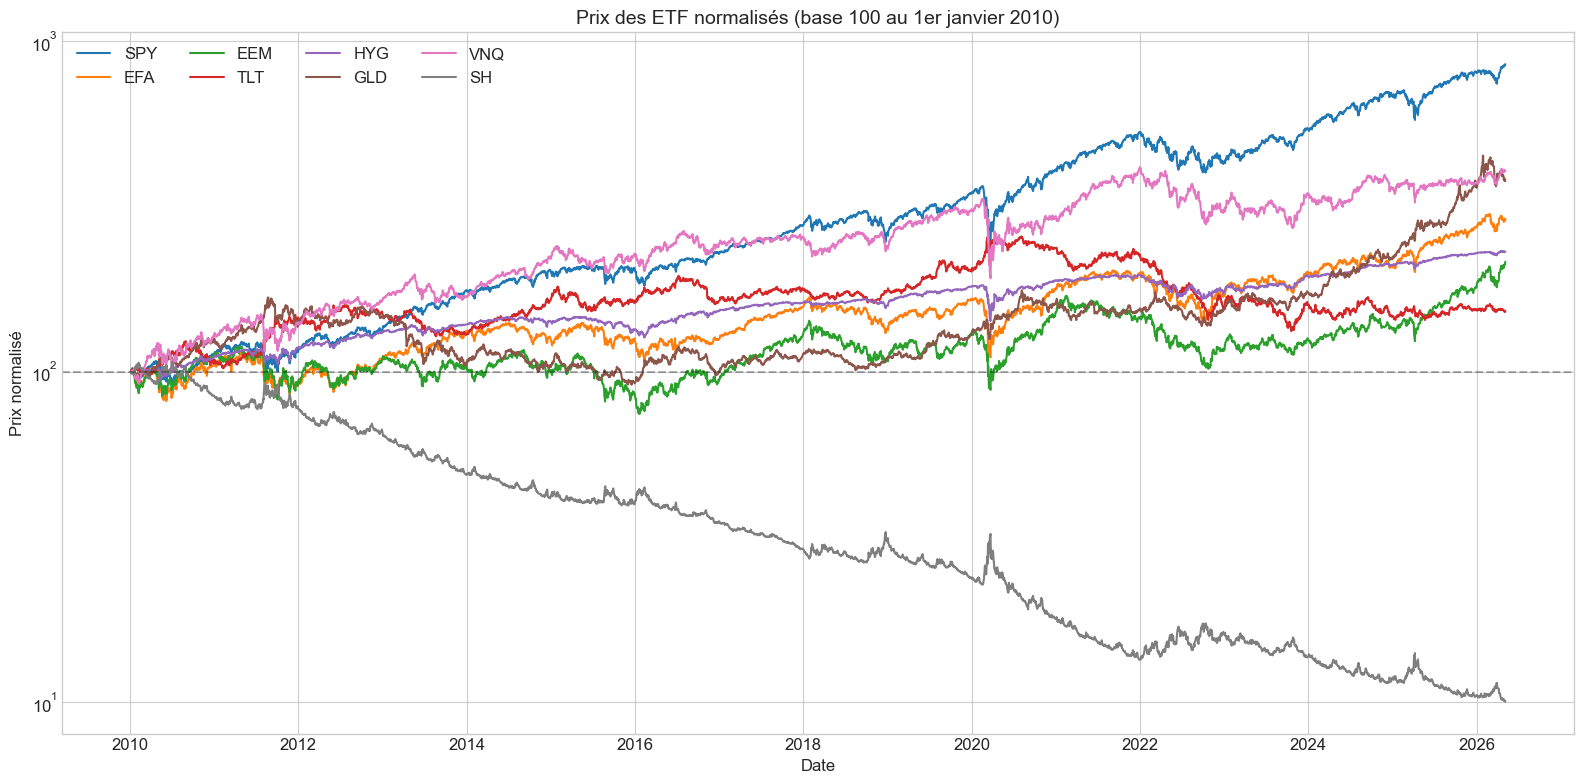

In [4]:
# Normaliser les prix (base 100 au début)
prices_norm = prices / prices.iloc[0] * 100

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

for ticker in ETF_TICKERS:
    ax.plot(prices_norm.index, prices_norm[ticker], label=ticker, linewidth=1.5)

ax.axhline(100, color='black', linestyle='--', alpha=0.3)
ax.set_title('Prix des ETF normalisés (base 100 au 1er janvier 2010)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Prix normalisé')
ax.legend(loc='upper left', ncol=4)
ax.set_yscale('log')  # Échelle log pour mieux voir les variations
plt.tight_layout()
plt.show()

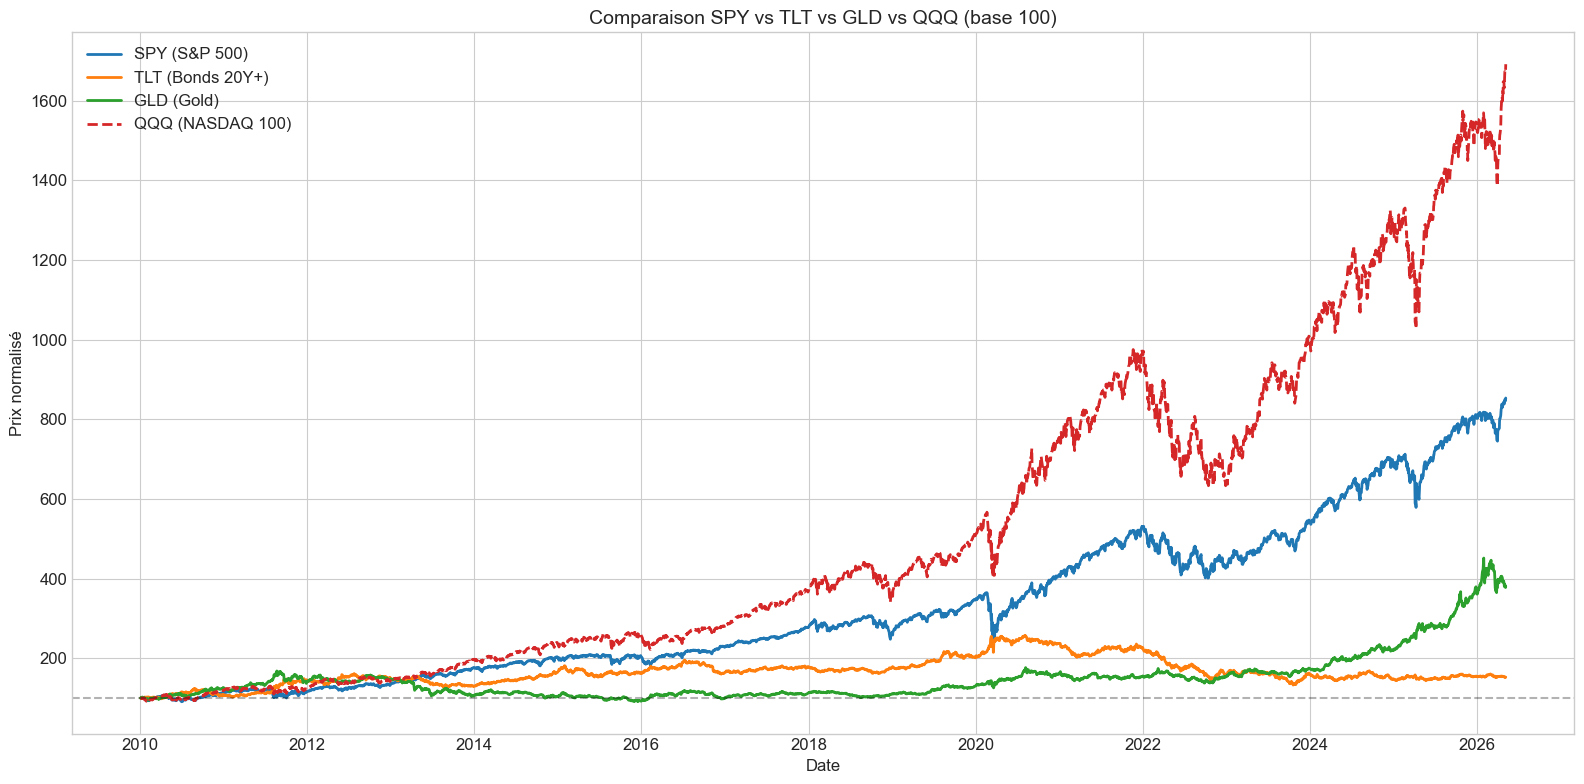

In [5]:
# Comparaison avec benchmarks
fig, ax = plt.subplots(figsize=(16, 8))

# ETF principaux
ax.plot(prices_norm.index, prices_norm['SPY'], label='SPY (S&P 500)', linewidth=2)
ax.plot(prices_norm.index, prices_norm['TLT'], label='TLT (Bonds 20Y+)', linewidth=2)
ax.plot(prices_norm.index, prices_norm['GLD'], label='GLD (Gold)', linewidth=2)

# Benchmarks
if 'QQQ' in prices_norm.columns:
    ax.plot(prices_norm.index, prices_norm['QQQ'], label='QQQ (NASDAQ 100)', linewidth=2, linestyle='--')

ax.axhline(100, color='black', linestyle='--', alpha=0.3)
ax.set_title('Comparaison SPY vs TLT vs GLD vs QQQ (base 100)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Prix normalisé')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Statistiques descriptives

In [6]:
# Calculer les returns journaliers
returns = prices[ETF_TICKERS].pct_change().dropna()

# Statistiques
stats = pd.DataFrame({
    'Return annualisé (%)': returns.mean() * 252 * 100,
    'Volatilité annualisée (%)': returns.std() * np.sqrt(252) * 100,
    'Sharpe (rf=0)': (returns.mean() * 252) / (returns.std() * np.sqrt(252)),
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis(),
    'Min daily (%)': returns.min() * 100,
    'Max daily (%)': returns.max() * 100,
}).round(2)

stats.sort_values('Sharpe (rf=0)', ascending=False)

,Return annualisé (%),Volatilité annualisée (%),Sharpe (rf=0),Skewness,Kurtosis,Min daily (%),Max daily (%)
SPY,14.63,17.15,0.85,-0.33,12.06,-10.94,10.50
HYG,5.48,8.27,0.66,-0.08,19.60,-5.50,6.55
GLD,9.58,16.53,0.58,-0.57,6.37,-10.27,6.36
VNQ,10.70,20.39,0.52,-0.74,15.62,-17.73,9.10
EFA,8.24,18.40,0.45,-0.57,9.19,-10.99,8.47
EEM,7.01,21.41,0.33,-0.34,5.90,-12.48,8.05
TLT,3.72,15.00,0.25,0.05,3.55,-6.67,7.52
SH,-12.61,17.22,-0.73,0.36,12.44,-9.35,11.51


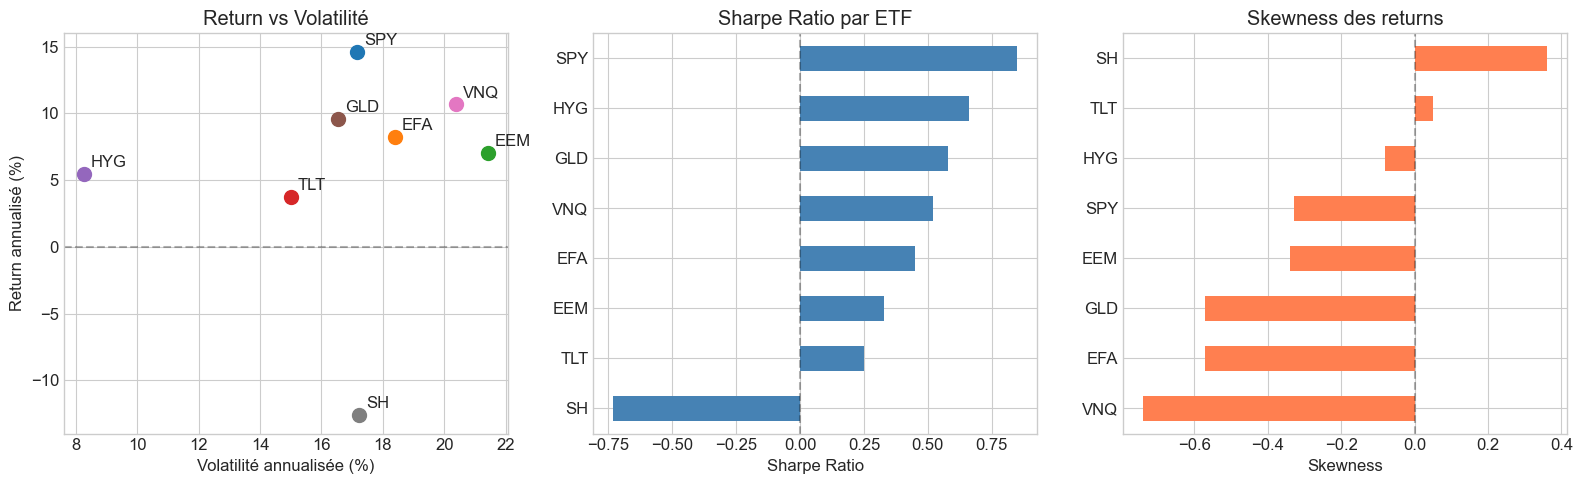

In [7]:
# Visualisation des stats
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Return vs Volatilité
ax = axes[0]
for ticker in ETF_TICKERS:
    ax.scatter(stats.loc[ticker, 'Volatilité annualisée (%)'], 
               stats.loc[ticker, 'Return annualisé (%)'],
               s=100, label=ticker)
    ax.annotate(ticker, (stats.loc[ticker, 'Volatilité annualisée (%)'], 
                         stats.loc[ticker, 'Return annualisé (%)']),
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Volatilité annualisée (%)')
ax.set_ylabel('Return annualisé (%)')
ax.set_title('Return vs Volatilité')
ax.axhline(0, color='black', linestyle='--', alpha=0.3)

# Sharpe Ratio
ax = axes[1]
stats['Sharpe (rf=0)'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio par ETF')
ax.axvline(0, color='black', linestyle='--', alpha=0.3)

# Skewness
ax = axes[2]
stats['Skewness'].sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Skewness')
ax.set_title('Skewness des returns')
ax.axvline(0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Drawdowns

In [8]:
def compute_drawdown(prices_series):
    """Calcule le drawdown (pic-à-creux) d'une série de prix."""
    cummax = prices_series.cummax()
    drawdown = (prices_series - cummax) / cummax
    return drawdown

# Calculer les drawdowns
drawdowns = pd.DataFrame()
for ticker in ETF_TICKERS:
    drawdowns[ticker] = compute_drawdown(prices[ticker])

# Max drawdown par ETF
max_dd = (drawdowns.min() * 100).round(1)
print("Max Drawdown (%):\n")
print(max_dd.sort_values())

Max Drawdown (%):

SH    -90.6
TLT   -48.4
GLD   -45.6
VNQ   -42.4
EEM   -39.8
EFA   -34.2
SPY   -33.7
HYG   -22.0
dtype: float64


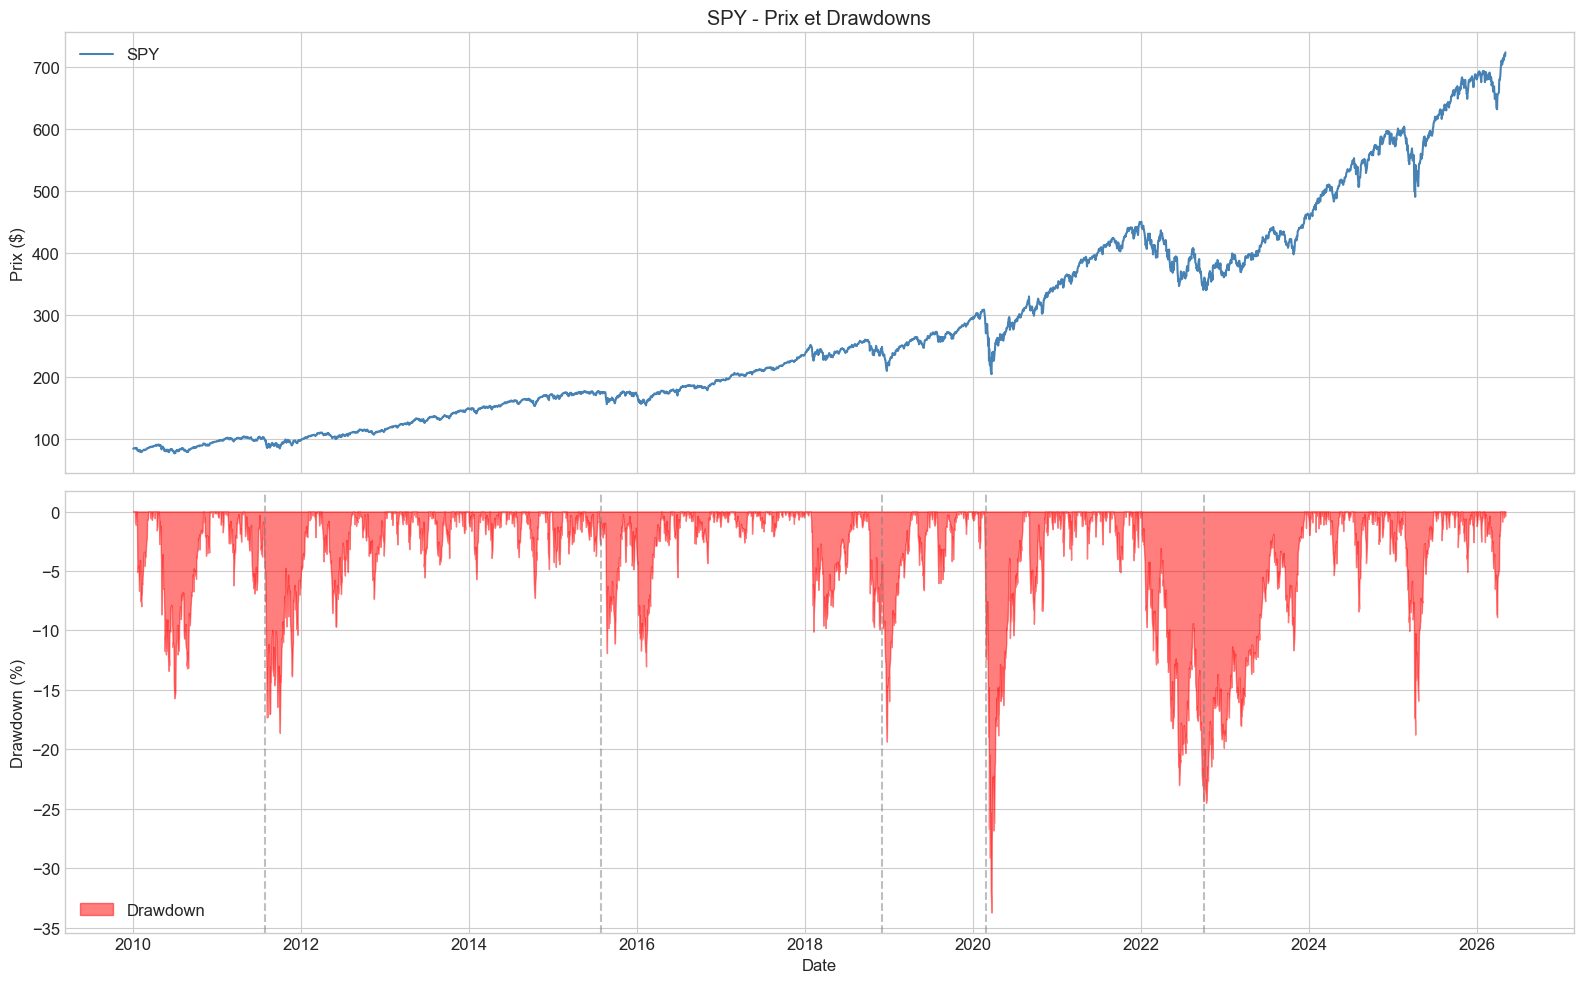

In [9]:
# Visualisation des drawdowns
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Prix SPY
ax = axes[0]
ax.plot(prices.index, prices['SPY'], label='SPY', color='steelblue')
ax.set_ylabel('Prix ($)')
ax.set_title('SPY - Prix et Drawdowns')
ax.legend(loc='upper left')

# Drawdown SPY
ax = axes[1]
ax.fill_between(drawdowns.index, drawdowns['SPY'] * 100, 0, 
                color='red', alpha=0.5, label='Drawdown')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(loc='lower left')

# Marquer les crises majeures
crises = [
    ('2011-08', 'Crise dette EU'),
    ('2015-08', 'Flash crash Chine'),
    ('2018-12', 'Correction Q4'),
    ('2020-03', 'COVID-19'),
    ('2022-10', 'Bear market'),
]
for date, label in crises:
    ax.axvline(pd.Timestamp(date), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Insights clés

**Observations :**

1. **SPY** (S&P 500) : Meilleure performance long terme (~10-12% annualisé), mais volatilité modérée (~15-18%)

2. **TLT** (Obligations longues) : Performance plus faible mais décorrélée des actions - utile en période de crise

3. **GLD** (Or) : Refuge en période d'incertitude, corrélation faible avec actions

4. **SH** (Short S&P 500) : Performance négative à long terme (décroissance structurelle), mais utile en bear market

5. **Drawdowns majeurs** : COVID-19 (mars 2020) avec -34% sur SPY, récupération rapide

6. **Skewness négative** : Tous les ETF actions ont une skewness négative (risque de queue gauche)